<a href="https://colab.research.google.com/github/ViacheslavPomazan/E-commerce_Conversion_Funnel-BigQuery-Google_Colab_Project/blob/main/eCommerce_Conversion_Funnel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project was initially developed as a training exercise in SQL and BigQuery, which is why it includes extensive SQL code. Google Colab was used as the publishing environment. Later, I enhanced the project by processing queries with Python and creating visualizations, giving it a more polished and comprehensive presentation. Different visualization libraries are used for educational purposes.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
from google.cloud import bigquery
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

Authenticated


In [ ]:
project_id = "flowing-precept-465603-c8"
client = bigquery.Client(project=project_id)


###**1. Sessions distribution by country, traffic channel and device category**.<br>
###**Conversion funnel.**

In [ ]:
# project_id = "flowing-precept-465603-c8"
# client = bigquery.Client(project=project_id)
query = """
    SELECT timestamp_micros(event_timestamp) AS event_timestamp, user_pseudo_id || '+' ||
    (SELECT value.int_value FROM UNNEST(event_params) WHERE key = 'ga_session_id') AS user_session_id,
    event_name, geo.country AS country, device.category AS device_category,
    traffic_source.source AS source, traffic_source.medium AS medium, traffic_source.name AS campaign
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_2021*`
ORDER BY event_timestamp
"""
query_job = client.query(query)
df = query_job.to_dataframe()
df

,event_timestamp,user_session_id,event_name,country,device_category,source,medium,campaign
0,2021-01-01 00:00:08.136569+00:00,63015181.0708404281+8529617896,page_view,India,mobile,google,organic,(organic)
1,2021-01-01 00:00:08.136569+00:00,63015181.0708404281+8529617896,first_visit,India,mobile,google,organic,(organic)
2,2021-01-01 00:00:08.136569+00:00,63015181.0708404281+8529617896,session_start,India,mobile,google,organic,(organic)
3,2021-01-01 00:00:12.955465+00:00,63015181.0708404281+8529617896,page_view,India,mobile,google,organic,(organic)
4,2021-01-01 00:00:12.955465+00:00,63015181.0708404281+8529617896,view_promotion,India,mobile,google,organic,(organic)
...,...,...,...,...,...,...,...,...
1210142,2021-01-31 23:59:54.824131+00:00,8728288.1164272892+5432345036,page_view,United States,desktop,<Other>,organic,(organic)
1210143,2021-01-31 23:59:54.824131+00:00,8728288.1164272892+5432345036,view_promotion,United States,desktop,<Other>,organic,(organic)
1210144,2021-01-31 23:59:55.412363+00:00,38749961.2390394784+6957760072,user_engagement,Jordan,mobile,shop.googlemerchandisestore.com,referral,(referral)
1210145,2021-01-31 23:59:55.412363+00:00,38749961.2390394784+6957760072,page_view,Jordan,mobile,shop.googlemerchandisestore.com,referral,(referral)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1210147 entries, 0 to 1210146
Data columns (total 8 columns):
 #   Column           Non-Null Count    Dtype              
---  ------           --------------    -----              
 0   event_timestamp  1210147 non-null  datetime64[us, UTC]
 1   user_session_id  1210147 non-null  object             
 2   event_name       1210147 non-null  object             
 3   country          1210147 non-null  object             
 4   device_category  1210147 non-null  object             
 5   source           1210147 non-null  object             
 6   medium           1210147 non-null  object             
 7   campaign         1210147 non-null  object             
dtypes: datetime64[us, UTC](1), object(7)
memory usage: 73.9+ MB


In [ ]:
df.agg({'event_timestamp':['min', 'max']})

,event_timestamp
min,2021-01-01 00:00:08.136569+00:00
max,2021-01-31 23:59:55.412363+00:00


In [ ]:
df[df.duplicated()].shape

(0, 8)

####Distribution of sessions by country

In [ ]:
df_country_session = df.groupby(by='country', as_index=False)['user_session_id'].nunique()
df_country_session.rename(columns={'user_session_id':'session_count'}, inplace=True)
df_country_session.sort_values('session_count', ascending=False)

,country,session_count
105,United States,52118
43,India,11013
18,Canada,8742
104,United Kingdom,3720
33,France,2318
...,...,...
14,Bosnia & Herzegovina,19
39,Honduras,19
77,Paraguay,19
62,Malta,18


Distribution of sessions and purchases by country

In [ ]:
df_purchase = df[df['event_name']=='purchase']
df_country_purchase = df_purchase.groupby(by= 'country', as_index=False)['event_name'].count()
df_country_purchase.rename(columns={'event_name':'purchases'}, inplace=True)
df_country = pd.merge(df_country_session, df_country_purchase, on='country', how='left').fillna(0)
df_country['purchases'] = df_country['purchases'].astype(int)
print(f'Overall number of purchases: ')
print(df_country['purchases'].sum())
# Find top source and its session count per country
df_country_source = df.groupby(by=['country', 'source'], as_index=False)['user_session_id'].nunique()
df_country_source.rename(columns={'user_session_id':'source_session_count'}, inplace=True)
df_country_source_max = df_country_source.groupby(by='country', as_index=False)['source_session_count'].max()
#df_country_source_max
df_1 = pd.merge(df_country_source,df_country_source_max, on=['country', 'source_session_count'])
df_1.drop_duplicates(subset='country', keep='first', inplace=True)
# df_1

df_plot = pd.merge(df_country, df_1, on='country')
df_plot.rename(columns={'source':'top_source', 'source_session_count':'top_source_count'}, inplace=True)
df_plot.sort_values('session_count', ascending= False)


Overall number of purchases: 
1204


,country,session_count,purchases,top_source,top_source_count
105,United States,52118,513,google,18832
43,India,11013,80,google,3974
18,Canada,8742,111,google,3215
104,United Kingdom,3720,35,google,1360
33,France,2318,23,google,851
...,...,...,...,...,...
14,Bosnia & Herzegovina,19,0,google,9
39,Honduras,19,0,google,7
77,Paraguay,19,0,google,9
62,Malta,18,0,google,9


####Session and purchase distribution map by country

In [ ]:
# Use a logarithmic color scale due to the much higher number of sessions in the USA
df_plot['log_session_count'] = np.log10(df_plot['session_count'] + 1)

fig = px.choropleth(
    df_plot,
    locations='country',
    locationmode='country names',
    color='log_session_count',
    hover_name='country',
    hover_data={'country': False, 'log_session_count': False, 'session_count': True, 'purchases': True,
                'top_source': True, 'top_source_count': True},
    color_continuous_scale=px.colors.sequential.Plasma,
    # title='Distribution of unique sessions by country',
    width=1200,
    height=700
)

fig.update_layout(
    coloraxis_colorbar=dict(
        title="Session Count",
        # logarithmic function:
        tickvals=np.log10(np.array([100, 1000, 10000, 50000])), # Label positions
        ticktext=['100', '1,000', '10,000', '50,000+'], # Custom labels
        tickformat='.0f',
        )
)
# Legend
fig.update_layout(
    title={
        'text': 'Session and purchase distribution',
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {
            'size': 24,
            'color': 'black'
        }
    })
fig.show()


**Conclusion:** With over 52,000 sessions, the USA significantly outperforms all other countries. Engagement across the African continent remains minimal. Google serves as the primary traffic source for the majority of countries.

####Distribution of sessions by device category.

In [ ]:
df_device = df.groupby(by='device_category', as_index=False)['user_session_id'].nunique()
df_device.rename(columns={'user_session_id':'session_count'}, inplace=True)
df_device.sort_values('session_count', ascending=False)

,device_category,session_count
0,desktop,68649
1,mobile,47088
2,tablet,2643


####Distribution of sessions by source/medium

In [ ]:
df_source_medium = df.groupby(by=['source', 'medium'], as_index= False)['user_session_id'].nunique()
df_source_medium['source/medium'] = df_source_medium['source'].str.cat(df_source_medium['medium'], sep='/')
df_source_medium = df_source_medium.rename(columns={'user_session_id': 'session_count'})
df_source_medium


,source,medium,session_count,source/medium
0,(data deleted),(data deleted),6371,(data deleted)/(data deleted)
1,(direct),(none),27593,(direct)/(none)
2,<Other>,(data deleted),95,<Other>/(data deleted)
3,<Other>,<Other>,17690,<Other>/<Other>
4,<Other>,organic,3520,<Other>/organic
5,<Other>,referral,11327,<Other>/referral
6,google,cpc,5243,google/cpc
7,google,organic,37614,google/organic
8,shop.googlemerchandisestore.com,referral,8927,shop.googlemerchandisestore.com/referral


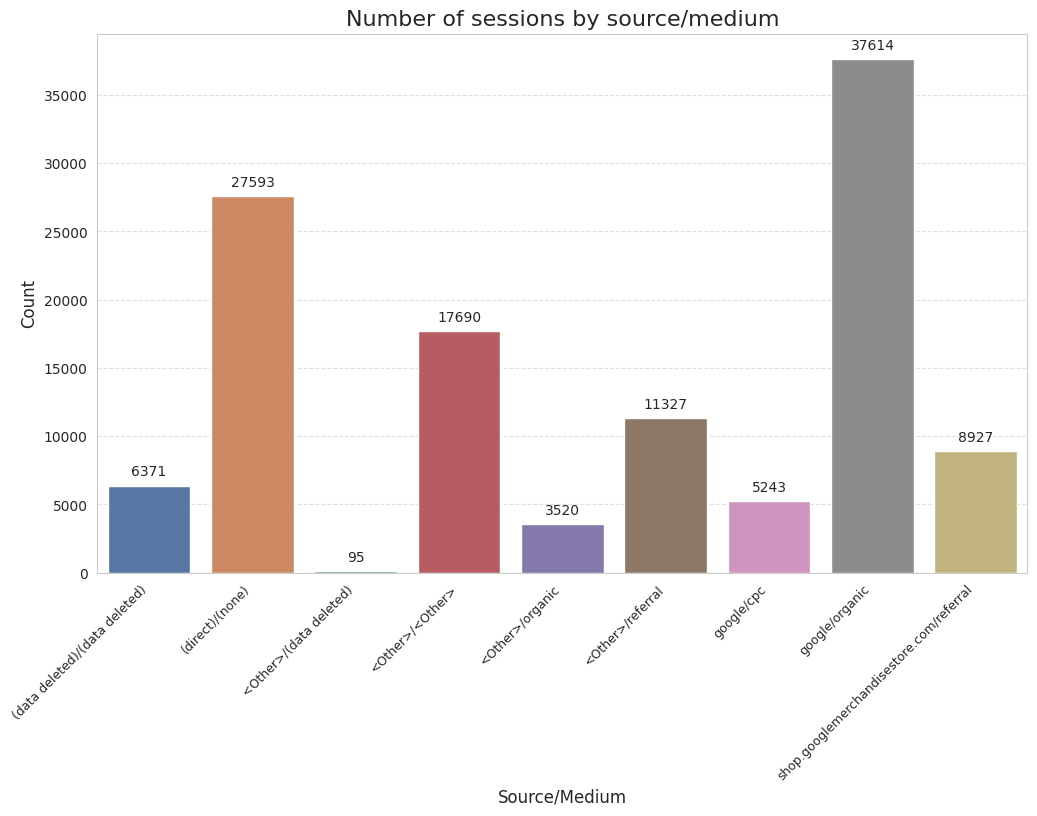

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=df_source_medium,
    x='source/medium',
    y='session_count',
    hue='source/medium',
    # dodge=False,
    palette='deep'
)

# plt.xticks(fontsize=9)
plt.xticks(rotation=45, ha='right', fontsize=9)

# Add the legend
plt.title('Number of sessions by source/medium', fontsize=16)
plt.xlabel('Source/Medium', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add the value atop a bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.0f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points'
    )

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Conclusion:** Traffic from unpaid search results on Google lead with more than 37000 sessions. Traffic from users who typed your URL directly where the medium is not explicitly defined takes second place.

####Conversion Funnel by 'event_name' and 'device_category'.

In [ ]:
df_group_2 = df.groupby(['event_name', 'device_category']).nunique('user_session_id')
s_event_count1 = df_group_2['user_session_id']
s_event_count = s_event_count1.rename('event_count')
#print(type(s_event_count))
#  Sum by event_name
event_totals = s_event_count.groupby(level='event_name').sum()
#  Create an auxiliary sorting level by total event_count for each event_name
s_event_count = s_event_count.reset_index()
s_event_count['event_total'] = s_event_count['event_name'].map(event_totals)
#  Sort by total (desc), then event_name, then device_category
df_event_count = s_event_count.sort_values(by=['event_total', 'event_name', 'device_category'],
    ascending=[False, True, True])
#s_event_count = s_event_count.set_index(['event_name', 'device_category'])['event_count']
df_event_count

,event_name,device_category,event_count,event_total
33,session_start,desktop,67590,116514
34,session_start,mobile,46331,116514
35,session_start,tablet,2593,116514
18,page_view,desktop,64488,111200
19,page_view,mobile,44237,111200
20,page_view,tablet,2475,111200
15,first_visit,desktop,51484,88853
16,first_visit,mobile,35354,88853
17,first_visit,tablet,2015,88853
36,user_engagement,desktop,50833,87634


In [ ]:
# Get max event_count per device_category
# s_event_count = df_event_count.set_index(['event_name', 'device_category'])['event_count']
device_max = s_event_count.groupby(by='device_category')['event_count'].max()
print(device_max)
#s_event_count = s_event_count.reset_index()
s_event_count['device_max'] = s_event_count['device_category'].map(device_max)
s_event_count = s_event_count.sort_values(['event_total', 'device_category'], ascending= [False, True])
#print(s_event_count)
# Calculate conversion for each device_category
s_event_count['CR'] = round(100 *s_event_count['event_count'] / s_event_count['device_max'], 2)
#print(type(s_event_count))


device_category
desktop    67590
mobile     46331
tablet      2593
Name: event_count, dtype: int64


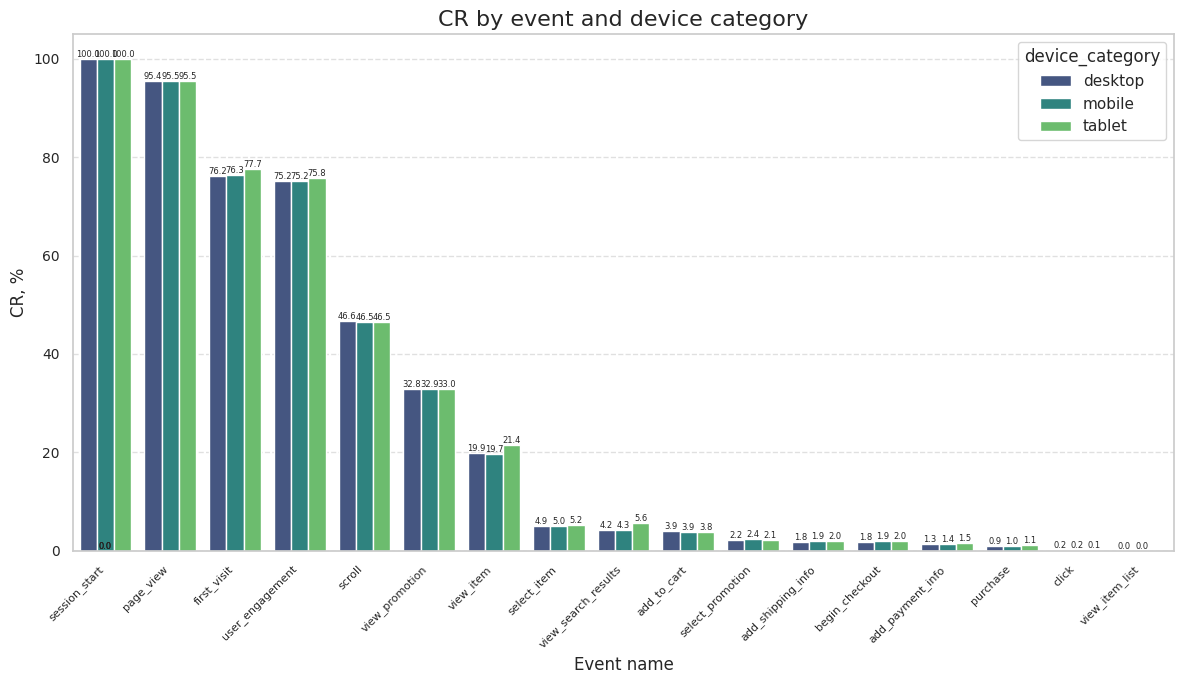

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))
ax = sns.barplot(data=s_event_count, x='event_name', y='CR', hue= 'device_category', palette="viridis")
plt.title('CR by event and device category',fontsize =16)
plt.xlabel('Event name', fontsize=12)
plt.ylabel('CR, %', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=10)
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,   # center by X
        p.get_height(),                  # top by Y
        #p.get_height(),             # value
        f'{p.get_height():.1f}',
        ha='center', va='bottom', fontsize=6
    )
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Conclusion:** All funnel metrics are at the lower end of market benchmarks. The funnel start (add_to_cart = 3.9%) is below the market average (5%). Conversions across all device categories are at the same level

In [ ]:
df_group_22 = df.groupby(['event_name', 'source']).nunique('user_session_id')
s_event_count11 = df_group_22['user_session_id']
s_event_count = s_event_count11.rename('event_count')
#print(type(s_event_count))
#  Sum by event_name
event_totals = s_event_count.groupby(level='event_name').sum()
#  Create an auxiliary sorting level by total event_count for each event_name
s_event_count = s_event_count.reset_index()
s_event_count['event_total'] = s_event_count['event_name'].map(event_totals)
#  Sort by total (desc), then event_name, then source
df_event_count = s_event_count.sort_values(by=['event_total', 'event_name', 'source'],
    ascending=[False, True, True])
#s_event_count = s_event_count.set_index(['event_name', 'source'])['event_count']
df_event_count

,event_name,source,event_count,event_total
55,session_start,(data deleted),6003,116514
56,session_start,(direct),27206,116514
57,session_start,<Other>,32270,116514
58,session_start,google,42392,116514
59,session_start,shop.googlemerchandisestore.com,8643,116514
...,...,...,...,...
24,click,shop.googlemerchandisestore.com,14,189
70,view_item_list,(data deleted),1,7
71,view_item_list,(direct),3,7
72,view_item_list,<Other>,2,7


In [ ]:
source_max = s_event_count.groupby(by='source')['event_count'].max()
print(source_max)
#s_event_count = s_event_count.reset_index()
s_event_count['source_max'] = s_event_count['source'].map(source_max)
s_event_count = s_event_count.sort_values(['event_total', 'source'], ascending= [False, True])
#print(s_event_count)
# Calculate conversion for each device_category
s_event_count['CR'] = round(100 *s_event_count['event_count'] / s_event_count['source_max'], 2)
#print(type(s_event_count))

source
(data deleted)                      6003
(direct)                           27206
<Other>                            32270
google                             42392
shop.googlemerchandisestore.com     8643
Name: event_count, dtype: int64


In [ ]:
# sns.set_theme(style="whitegrid")
# plt.figure(figsize=(12, 7))
# ax = sns.barplot(data=s_event_count, x='event_name', y='CR', hue= 'source', palette="deep")
# plt.title('CR by event and source',fontsize =16)
# plt.xlabel('Event name', fontsize=12)
# plt.ylabel('CR, %', fontsize=12)
# plt.xticks(rotation=45, ha='right', fontsize=8)
# plt.yticks(fontsize=10)
# for p in ax.patches:
#     ax.text(
#         p.get_x() + p.get_width() / 2,   # center by X
#         p.get_height(),                  # top by Y
#         #p.get_height(),             # value
#         f'{p.get_height():.0f}',
#         ha='center', va='bottom', fontsize=6
#     )
# plt.grid(axis='y', linestyle='--', alpha=0.6)
# plt.tight_layout()
# plt.show()

In [ ]:
fig = px.bar(
    s_event_count,
    x='event_name',
    y='CR',
    color='source',
    barmode='group',
    title='CR by event and source',
    width=1200,
    height=700,
    color_discrete_sequence=px.colors.qualitative.Dark2
)
# Tooltips(Hover Data):
# fig.update_traces(hovertemplate='<b>Event: %{x}</b><br>Source: %{customdata[0]}<br>CR: %{y:.2f}%<extra></extra>',
#                   customdata=s_event_count[['source']].values)

# Labels atop bars
# fig.update_traces(
#     texttemplate='%{y:.0f}',
#     textposition='outside'
# )

# General appearance settings
fig.update_layout(
    title_font_size=16,
    xaxis_title='Event name',
    yaxis_title='CR, %',
    xaxis_tickangle=-45,
    plot_bgcolor='white',
    #xaxis=dict(gridcolor='lightgray'),
    yaxis=dict(gridcolor='lightgray',  griddash='dot')
)

fig.show()

**Conclision:** Conversion rate across source (data deleted) is higher than others.

###2. **Calculation of conversions by dates and traffic channels**<br>
####Option 1<br>
I count unique sessions and 'session_start', since the 'session_start' event may be absent in some sessions.<br>
Conversion calculated relative to 'session_start'.

In [ ]:
query3_1 = """
WITH init AS (
      SELECT date(timestamp_micros(event_timestamp)) as event_date,
            traffic_source.source AS source,traffic_source.medium AS medium, traffic_source.name AS campaign,
            user_pseudo_id || (SELECT value.int_value FROM t.event_params  WHERE  key='ga_session_id') AS user_session_id,
            event_name
      FROM  `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_2021*` t
      )
SELECT event_date, source, medium, campaign,
      count(distinct user_session_id) as user_sessions_count,
      count(distinct case when event_name = 'session_start' then user_session_id end) as session_start,
      coalesce(count(distinct case when event_name = 'add_to_cart' then user_session_id end), 0) /
                  nullif(count(distinct case when event_name = 'session_start' then user_session_id end), 0) as add_to_cart,
      coalesce(count(distinct case when event_name = 'begin_checkout' then user_session_id end), 0) /
                  nullif(count(distinct case when event_name = 'session_start' then user_session_id end), 0) as begin_checkout,
      coalesce(count(distinct case when event_name = 'add_shipping_info' then user_session_id end), 0) /
                  nullif(count(distinct case when event_name = 'session_start' then user_session_id end), 0) as add_shipping_info,
      coalesce(count(distinct case when event_name = 'add_payment_info' then user_session_id end), 0) /
                  nullif(count(distinct case when event_name = 'session_start' then user_session_id end), 0) as add_payment_info,
      coalesce(count(distinct case when event_name = 'purchase' then user_session_id end), 0) /
                  nullif(count(distinct case when event_name = 'session_start' then user_session_id end), 0) as purchase
FROM init
GROUP BY event_date, source, medium, campaign
ORDER BY event_date, source, medium
"""
query_job = client.query(query3_1)
df_2 = query_job.to_dataframe()
df_2

,event_date,source,medium,campaign,user_sessions_count,session_start,add_to_cart,begin_checkout,add_shipping_info,add_payment_info,purchase
0,2021-01-01,(data deleted),(data deleted),(data deleted),85,85,0.058824,0.023529,0.023529,0.023529,0.023529
1,2021-01-01,(data deleted),(data deleted),<Other>,3,3,0.000000,0.000000,0.000000,0.000000,0.000000
2,2021-01-01,(direct),(none),(direct),571,564,0.042553,0.015957,0.015957,0.010638,0.008865
3,2021-01-01,<Other>,(data deleted),(data deleted),2,2,0.000000,0.000000,0.000000,0.000000,0.000000
4,2021-01-01,<Other>,<Other>,<Other>,380,377,0.018568,0.015915,0.015915,0.005305,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
299,2021-01-31,<Other>,organic,(organic),67,67,0.014925,0.014925,0.014925,0.000000,0.000000
300,2021-01-31,<Other>,referral,(referral),265,256,0.015625,0.015625,0.015625,0.007812,0.000000
301,2021-01-31,google,cpc,<Other>,154,152,0.006579,0.006579,0.006579,0.006579,0.000000
302,2021-01-31,google,organic,(organic),910,888,0.036036,0.016892,0.016892,0.010135,0.004505


In [ ]:
unique_combinations = df_2[['source', 'medium', 'campaign']].drop_duplicates()
#  result as NumPy array:
unique_combinations_array = unique_combinations.values
print(unique_combinations)

                            source          medium        campaign
0                   (data deleted)  (data deleted)  (data deleted)
1                   (data deleted)  (data deleted)         <Other>
2                         (direct)          (none)        (direct)
3                          <Other>  (data deleted)  (data deleted)
4                          <Other>         <Other>         <Other>
5                          <Other>         organic       (organic)
6                          <Other>        referral      (referral)
7                           google             cpc         <Other>
8                           google         organic       (organic)
9  shop.googlemerchandisestore.com        referral      (referral)


In [ ]:
N = df_2['user_sessions_count'].sum() - df_2['session_start'].sum()
print(f'Number of sessions without session_start : {N}')

Number of sessions without session_start : 2104


Number of sessions by 'source', 'medium', 'campaign'.

In [ ]:
df_source_medium_camp = df.groupby(by=['source', 'medium', 'campaign'], as_index= False)['user_session_id'].nunique()
df_source_medium_camp

,source,medium,campaign,user_session_id
0,(data deleted),(data deleted),(data deleted),6232
1,(data deleted),(data deleted),<Other>,139
2,(direct),(none),(direct),27593
3,<Other>,(data deleted),(data deleted),95
4,<Other>,<Other>,<Other>,17690
5,<Other>,organic,(organic),3520
6,<Other>,referral,(referral),11327
7,google,cpc,<Other>,5243
8,google,organic,(organic),37614
9,shop.googlemerchandisestore.com,referral,(referral),8927


Only combination ((data deleted),	(data deleted)) for ('source', 'medium') has 2 different 'campaign'. Сombine them into one category and concatinate 'source' and 'medium' into one column.

In [ ]:
df_date_source_medium = df_2.groupby(by=['event_date', 'source', 'medium'], as_index= False)['purchase'].mean()
#df_date_source_medium.head(30)
df_date_source_medium['source/medium'] = df_date_source_medium['source'].str.cat(df_date_source_medium['medium'], sep='/')
df_plot_2 = df_date_source_medium.drop(columns=['source', 'medium']).rename(columns={'purchase': 'CR to purchase'})
df_plot_2.head()

,event_date,CR to purchase,source/medium
0,2021-01-01,0.011765,(data deleted)/(data deleted)
1,2021-01-01,0.008865,(direct)/(none)
2,2021-01-01,0.000000,<Other>/(data deleted)
3,2021-01-01,0.000000,<Other>/<Other>
4,2021-01-01,0.000000,<Other>/organic


In [ ]:
df_plot_2['CR to purchase'] = df_plot_2['CR to purchase'].apply(lambda x: round(x*100, 4))
fig = px.line(
    df_plot_2,
    x='event_date',
    y='CR to purchase',
    color='source/medium',
    title='Dynamics CR to purchase by Source/Medium',
    labels={
        'event_date': 'Event date',
        'CR to purchase': 'CR to purchase, %'
    },
    width=1000,
    height=600
)

fig.show()

**Conclusion:** There are emissions in two categories. These are combinations ((data deleted)	(data deleted)	Other) and (Other	(data deleted)	(data deleted))	, which have the fewest sessions - 139 and 95 respectively. You can filter them using the chart legend above. Below, I’ll show how to do it with code.

In [ ]:
df_2_copy = df_2.copy()
df_2_copy
df_2_copy_filt = df_2_copy[
    ~((df_2_copy['source'] == '(data deleted)') &
      (df_2_copy['medium'] == '(data deleted)') & (df_2_copy['campaign'] =='<Other>'))
]
df_2_copy_filt = df_2_copy_filt[
    ~((df_2_copy_filt['source'] == '<Other>') &
      (df_2_copy_filt['medium'] == '(data deleted)') & (df_2_copy_filt['campaign'] =='(data deleted)'))
]
df_2_copy_filt.head()

,event_date,source,medium,campaign,user_sessions_count,session_start,add_to_cart,begin_checkout,add_shipping_info,add_payment_info,purchase
0,2021-01-01,(data deleted),(data deleted),(data deleted),85,85,0.058824,0.023529,0.023529,0.023529,0.023529
2,2021-01-01,(direct),(none),(direct),571,564,0.042553,0.015957,0.015957,0.010638,0.008865
4,2021-01-01,<Other>,<Other>,<Other>,380,377,0.018568,0.015915,0.015915,0.005305,0.000000
5,2021-01-01,<Other>,organic,(organic),64,64,0.015625,0.000000,0.000000,0.000000,0.000000
6,2021-01-01,<Other>,referral,(referral),213,211,0.028436,0.004739,0.004739,0.004739,0.004739


Filtered data

In [ ]:
df_source_medium_camp = df_2_copy_filt.groupby(by=['source', 'medium', 'campaign'], as_index= False)['user_sessions_count'].sum()
df_source_medium_camp

,source,medium,campaign,user_sessions_count
0,(data deleted),(data deleted),(data deleted),6247
1,(direct),(none),(direct),27650
2,<Other>,<Other>,<Other>,17719
3,<Other>,organic,(organic),3527
4,<Other>,referral,(referral),11346
5,google,cpc,<Other>,5252
6,google,organic,(organic),37690
7,shop.googlemerchandisestore.com,referral,(referral),8953


Dataframe for diagram. After filtering, the combinations 'source', 'medium' remained unique, so grouping is not required. Concatinate 'source' and 'medium' into one column.

In [ ]:
df_2_plot = df_2_copy_filt[['event_date', 'source', 'medium', 'purchase']].copy()
df_2_plot['purchase_%'] = round(df_2_plot['purchase'] * 100, 2)
df_2_plot['source/medium'] = df_2_plot['source'].str.cat(df_2_plot['medium'], sep='/')
df_2_plot = df_2_plot.drop(columns=['source', 'medium', 'purchase']).rename(columns={'purchase_%': 'CR to purchase'})
df_2_plot.head()

,event_date,CR to purchase,source/medium
0,2021-01-01,2.35,(data deleted)/(data deleted)
2,2021-01-01,0.89,(direct)/(none)
4,2021-01-01,0.00,<Other>/<Other>
5,2021-01-01,0.00,<Other>/organic
6,2021-01-01,0.47,<Other>/referral


Trend line construction

In [ ]:

df_2_plot['event_date'] = pd.to_datetime(df_2_plot['event_date'])
#1. Creating a numeric representation of a date
df_trend = df_2_plot[['event_date', 'CR to purchase']].copy()
df_trend['date_numeric'] = pd.to_numeric(df_trend['event_date'])
# 2. Calculating the OLS (Linear Regression) line
slope, intercept = np.polyfit(df_trend['date_numeric'], df_trend['CR to purchase'], 1)
# 3. Calculating trend values ​​for display
# Create new points (y) based on the trend line (y = mx + b)
df_trend['trend'] = slope * df_trend['date_numeric'] + intercept
# Sort by date to display the line correctly
df_trend = df_trend.sort_values('event_date').drop_duplicates(subset=['event_date'], keep='first')


In [ ]:
import plotly.graph_objects as go

fig = px.line(
    df_2_plot,
    x='event_date',
    y='CR to purchase',
    color='source/medium',
    title='Dynamics CR to purchase by Source/Medium(filtered)',
    labels={
        'event_date': 'Event date',
        'CR to purchase': 'CR to purchase, %'
    },
    width=1200,
    height=700,
   )

fig.add_trace(
    go.Scatter(
        x=df_trend['event_date'],
        y=df_trend['trend'],
        mode='lines',
        name='Overall trend line (OLS)',
        line=dict(color='black', width=2, dash='dash')
    )
)
fig.show()

**Conclusion:** Traffic wihh (data deleted/data deleted) has higher CR than others. Overall trend line shows slight growth by month-end.

####**2. Calculation of conversions by dates and traffic channels**.<br>
####Option 2<br>
/Using the PIVOT operator. Counting only session_start*/

In [ ]:
query3_2 = """
SELECT p.event_date, p.sourse, p.medium, p.campaign, p.session_start,
        1.0 * coalesce(p.add_to_cart, 0) / nullif(p.session_start, 0) as add_to_cart,
        1.0 * coalesce(p.begin_checkout, 0) / nullif(p.session_start, 0) as begin_checkout,
        1.0 * coalesce(p.purchase, 0) /  nullif(p.session_start, 0) as purchase
FROM
(SELECT *  FROM
(SELECT date(timestamp_micros(event_timestamp)) as event_date, traffic_source.source AS sourse, traffic_source.medium AS medium, traffic_source.name AS campaign,
         event_name,
        COUNT(DISTINCT user_pseudo_id || (SELECT value.int_value FROM t.event_params  WHERE  key='ga_session_id')) as  count_user_session_id
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_2021*` t
WHERE event_name in ('session_start', 'add_to_cart', 'begin_checkout', 'purchase')
GROUP BY event_date, traffic_source.source, traffic_source.medium, traffic_source.name, event_name) e
PIVOT (SUM(count_user_session_id)
        FOR event_name IN ('session_start', 'add_to_cart', 'begin_checkout', 'purchase'))) p
ORDER BY event_date, sourse, medium
LIMIT 10
"""
query_job = client.query(query3_2)
df = query_job.to_dataframe()
df

,event_date,sourse,medium,campaign,session_start,add_to_cart,begin_checkout,purchase
0,2021-01-01,(data deleted),(data deleted),(data deleted),85,0.058824,0.023529,0.023529
1,2021-01-01,(data deleted),(data deleted),<Other>,3,0.000000,0.000000,0.000000
2,2021-01-01,(direct),(none),(direct),564,0.042553,0.015957,0.008865
3,2021-01-01,<Other>,(data deleted),(data deleted),2,0.000000,0.000000,0.000000
4,2021-01-01,<Other>,<Other>,<Other>,377,0.018568,0.015915,0.000000
5,2021-01-01,<Other>,organic,(organic),64,0.015625,0.000000,0.000000
6,2021-01-01,<Other>,referral,(referral),211,0.028436,0.004739,0.004739
7,2021-01-01,google,cpc,<Other>,103,0.019417,0.009709,0.009709
8,2021-01-01,google,organic,(organic),746,0.026810,0.010724,0.004021
9,2021-01-01,shop.googlemerchandisestore.com,referral,(referral),134,0.022388,0.000000,0.000000


####**2. Calculation of conversions by dates and traffic channels.**<br>
####Option 3<br>
/*This query counts only `session_start` events, groups the data,
-- and applies pivoting through aggregation.*/

In [ ]:
query3_3 = """
SELECT e1.event_date, e1.sourse, e1.medium, e1.campaign,
        min(case when event_name = 'session_start' then count_user_session_id end) as session_start,
        coalesce(min(case when event_name = 'add_to_cart' then count_user_session_id end), 0) /
            nullif(min(case when event_name = 'session_start' then count_user_session_id end), 0) as add_to_cart,
        coalesce(min(case when event_name = 'begin_checkout' then count_user_session_id end), 0) /
            nullif(min(case when event_name = 'session_start' then count_user_session_id end), 0) as begin_checkout,
        coalesce(min(case when event_name = 'purchase' then count_user_session_id end), 0) /
            nullif(min(case when event_name = 'session_start' then count_user_session_id end), 0) as purchase
FROM (
SELECT  date(timestamp_micros(event_timestamp)) as event_date,
         traffic_source.source AS sourse,traffic_source.medium AS medium, traffic_source.name AS campaign,
         event_name,
        COUNT(distinct user_pseudo_id || (SELECT value.int_value FROM t.event_params  WHERE  key='ga_session_id')) as  count_user_session_id
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_2021*` t
WHERE event_name in ('session_start', 'add_to_cart', 'begin_checkout', 'purchase')
GROUP BY event_date, traffic_source.source, traffic_source.medium, traffic_source.name, event_name) e1
GROUP BY event_date, sourse, medium, campaign
ORDER BY event_date,sourse, medium
LIMIT 10
"""
query_job = client.query(query3_3)
df = query_job.to_dataframe()
df

,event_date,sourse,medium,campaign,session_start,add_to_cart,begin_checkout,purchase
0,2021-01-01,(data deleted),(data deleted),(data deleted),85,0.058824,0.023529,0.023529
1,2021-01-01,(data deleted),(data deleted),<Other>,3,0.000000,0.000000,0.000000
2,2021-01-01,(direct),(none),(direct),564,0.042553,0.015957,0.008865
3,2021-01-01,<Other>,(data deleted),(data deleted),2,0.000000,0.000000,0.000000
4,2021-01-01,<Other>,<Other>,<Other>,377,0.018568,0.015915,0.000000
5,2021-01-01,<Other>,organic,(organic),64,0.015625,0.000000,0.000000
6,2021-01-01,<Other>,referral,(referral),211,0.028436,0.004739,0.004739
7,2021-01-01,google,cpc,<Other>,103,0.019417,0.009709,0.009709
8,2021-01-01,google,organic,(organic),746,0.026810,0.010724,0.004021
9,2021-01-01,shop.googlemerchandisestore.com,referral,(referral),134,0.022388,0.000000,0.000000


###3. **Comparison of conversion rates across different landing pages**<br>
####Option 1<br>
Use CASE to define session_start and purchase; if page_path is empty, set a slash '/'<br>
According to the task, the number of purchases equals unique sessions with a 'purchase' event; multiple purchases per session are ignored.

In [ ]:
query4_1 = """
WITH init AS (
  SELECT DISTINCT user_pseudo_id || (SELECT value.int_value FROM UNNEST(event_params) WHERE key = 'ga_session_id') AS user_session_id,
        CASE
            WHEN event_name = 'session_start'
            THEN '/' || REGEXP_EXTRACT(
                (SELECT value.string_value FROM UNNEST(event_params) WHERE key = 'page_location'),
                            r'^https?://[^/]+/([^?#]*)')
            ELSE null
        END AS page_path,
        CASE WHEN event_name = 'purchase' THEN 1 ELSE 0 END AS is_purchase
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_2021*`
    )
--З двох рядків по кожному user_session_id вибіраєм page_path не null і is_purchase= 1, якщо є покупка
, init1 AS (
    SELECT user_session_id, max(page_path) as page_path, max(is_purchase) AS is_purchase
    FROM init
    GROUP BY user_session_id
        )
--Якщо в сесії відсутній session_start, то page_path буде null.
--Можна відфільтрувати, але таких сесій немало і по ним є покупки, тому оставлчю як unknown
SELECT coalesce(page_path, 'unknown'), count(user_session_id) AS start_event, sum(is_purchase) AS purchase_event,
        sum(is_purchase) / nullif(count(user_session_id), 0) AS cr
FROM init1
GROUP BY page_path
ORDER BY purchase_event DESC, page_path
--LIMIT 10
"""
query_job = client.query(query4_1)
df = query_job.to_dataframe()
df.rename(columns = {'f0_':'page_path', 'start_event':'session_starts', 'purchase_event':'purchases'}, inplace=True)
df


,page_path,session_starts,purchases,cr
0,/,49640,657,0.013235
1,/basket.html,1390,48,0.034532
2,/Google+Redesign/Shop+by+Brand/Google,1038,30,0.028902
3,/store.html,5724,27,0.004717
4,/Google+Redesign/Clearance,914,25,0.027352
...,...,...,...,...
712,/topsellers/home,1,0,0.000000
713,/wishlist.html,7,0,0.000000
714,/yourinfo.html/home,2,0,0.000000
715,/youtube,1,0,0.000000


####CR by number of 'session_start'.

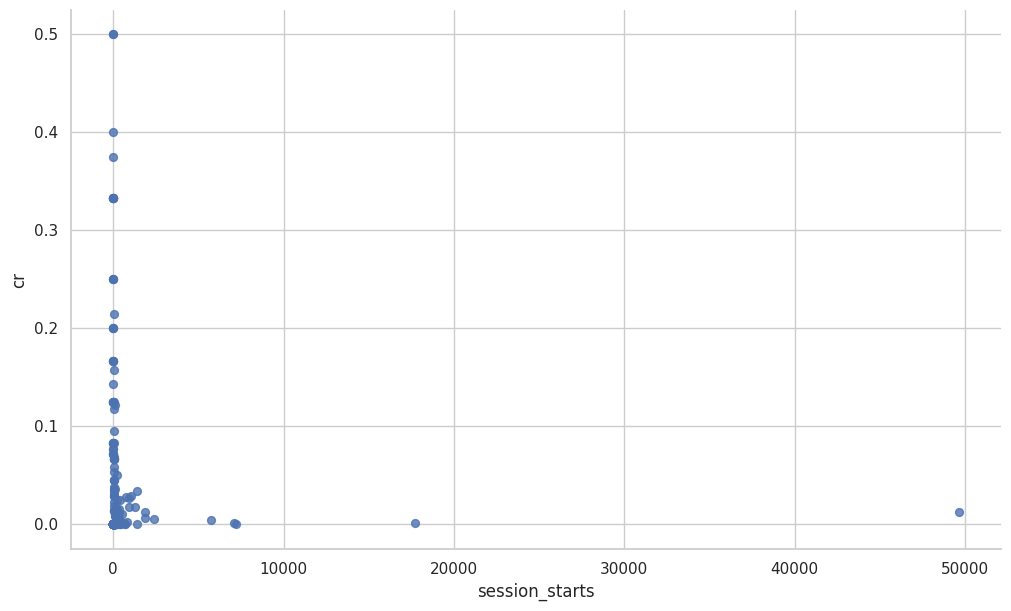

In [ ]:
from matplotlib import pyplot as plt
plt.figure(figsize=(12, 7))
df.plot(kind='scatter', x='session_starts', y='cr', s=32, alpha=.8, ax=plt.gca())
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()

####Plot for number of 'session_start' < 5000

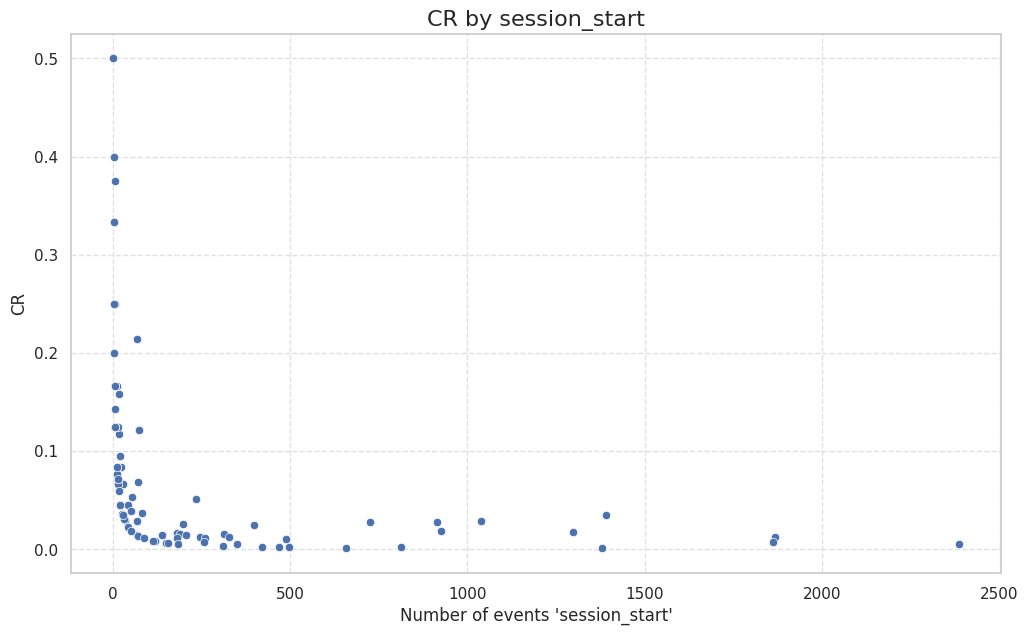

In [ ]:
df_plot = df[df['session_starts'] < 5000]
df_plot = df_plot[df_plot['cr'] > 0]
sns.set_style("whitegrid")
# Створюємо фігуру та осі для графіка
plt.figure(figsize=(12, 7))
ax = sns.scatterplot(
    data=df_plot,
    x='session_starts',
    y="cr",
#    palette='viridis'
)
# plt.xticks(fontsize=9)
# Додаємо назви та легенду
plt.title('CR by session_start', fontsize=16)
plt.ylabel('CR', fontsize=12)
plt.xlabel("Number of events 'session_start'", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


**Conclusion:** Pages with low usage (<50 session_starts) mostly demonstrate a CR above 0.05, while high-traffic pages (>500 session_starts) show a CR below 0.035. The page without a specified page_path shows a significantly higher number of session_starts (49,640) with its CR = 0.013.

####CR distribution

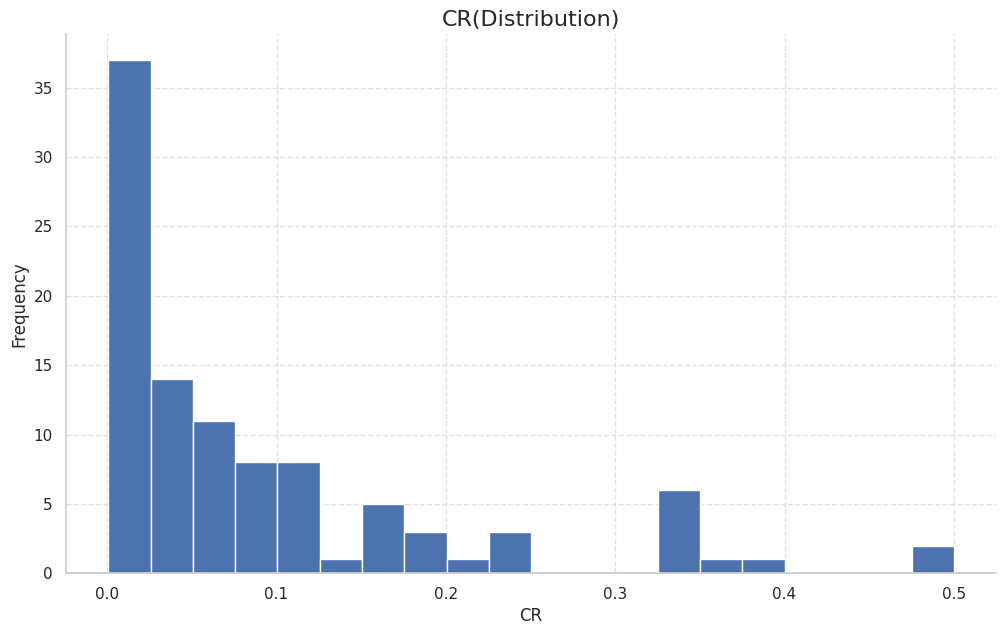

In [ ]:
df_plot = df_plot[df_plot['cr'] > 0]
plt.figure(figsize=(12, 7))
df_plot['cr'].plot(kind='hist', bins=20, title='cr', ax=plt.gca())
plt.gca().spines[['top', 'right',]].set_visible(False)

plt.title('CR(Distribution)', fontsize=16)
plt.xlabel('CR', fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
print('CR distribution for initial dataframe:')
print(df['cr'].describe())
print('\n')
print('CR distribution for pages with number of session_start < 5000 and CR > 0:')
print(df_plot['cr'].describe())

CR distribution for initial dataframe:
count    717.000000
mean       0.013372
std        0.054125
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.500000
Name: cr, dtype: float64


CR distribution for pages with number of session_start < 5000 and CR > 0:
count    101.000000
mean       0.094724
std        0.114859
min        0.000725
25%        0.014388
50%        0.045455
75%        0.125000
max        0.500000
Name: cr, dtype: float64


**Conclusion:** The majority of pages (616 out of 717) showed no purchase conversions. Among the pages with CR > 0 (101 pages), the median conversion rate is 0.045.

###Comparison of conversion rates across different landing pages.<br>
####Option 2<br>
 In this variant, sessions without session_start are filtered out immediately, but sessions with multiple session_start events having different 'page_location' still pass through. In the events_2020* table, there are 31 such sessions, resulting in 36 extra session_start events.  
 Therefore, we filter using ROW_NUMBER.

In [ ]:
query4_2 = """
WITH first_table AS (
  SELECT distinct user_pseudo_id || (SELECT value.int_value FROM UNNEST(event_params) WHERE key = 'ga_session_id') AS user_session_id,
        '/' || REGEXP_EXTRACT((SELECT value.string_value FROM UNNEST(event_params) WHERE key = 'page_location'),
                  r'^https?://[^/]+/([^?#]*)') AS page_path,
        ROW_NUMBER() OVER (PARTITION BY user_pseudo_id ||
              (SELECT value.int_value FROM UNNEST(event_params) WHERE key = 'ga_session_id') ) AS rn
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_2021*`
  WHERE event_name = 'session_start'
    )
, init AS (
  SELECT user_session_id, page_path
  FROM first_table
  WHERE rn = 1
)
--Співвідносим сторінки session_start з покупками через user_session_id
, purch_users AS (
  SELECT page_path, user_session_id
  FROM init  WHERE user_session_id in
          (SELECT user_pseudo_id || (SELECT value.int_value FROM UNNEST(event_params) WHERE key = 'ga_session_id')
            FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_2021*`
            WHERE event_name = 'purchase')
              )
--Рахуєм стартові сторінки
, start_users_count as (
      SELECT page_path, count(distinct user_session_id) as start_event
      FROM init
      GROUP BY page_path
      )
--Рахуєм кількість покупок по сторінкам
, purchers_users_count as (
  SELECT page_path, count(distinct user_session_id ) as purchase_event
  FROM purch_users
  GROUP BY page_path
    )
--З'єднуєм таблицю кількості page_path в session_start з таблицею кількості покупок в сесії, яка починалась з віповіного page_path .
SELECT s.page_path, s.start_event, coalesce(p.purchase_event, 0) as purchase_event,
          coalesce(p.purchase_event, 0) / nullif(s.start_event, 0) as cr
FROM start_users_count s left join purchers_users_count p using(page_path)
ORDER BY p.purchase_event desc, s.page_path
LIMIT 10
"""
print('Sorted by purchase descending')
query_job = client.query(query4_2)
df = query_job.to_dataframe()
df


Sorted by purchase descending


,page_path,start_event,purchase_event,cr
0,/,49642,657,0.013235
1,/basket.html,1390,48,0.034532
2,/Google+Redesign/Shop+by+Brand/Google,1038,30,0.028902
3,/store.html,5724,27,0.004717
4,/Google+Redesign/Clearance,915,25,0.027322
5,/Google+Redesign/Apparel/Mens,1297,23,0.017733
6,/Google+Redesign/Apparel,17692,22,0.001243
7,/Google+Redesign/New,725,20,0.027586
8,/signin.html,927,17,0.018339
9,/payment.html,70,15,0.214286


Note: Variants 1 and 2 show small differences in the number of starts for some page paths, but the overall total remains the same.
/*SUM(start_event_1) - unknown_start_event = SUM(start_event_2)*/

###4. **Purchase conversion correlation with engagement time and the presence of engagement in a session.**<br>
####Option 1 with JOIN

In [ ]:
query5_1 = """
WITH init AS (
      SELECT
            user_pseudo_id || (SELECT value.int_value FROM UNNEST(event_params) WHERE key = 'ga_session_id') AS user_session_id,
            max(coalesce(coalesce(
            safe_cast((SELECT value.string_value FROM UNNEST(event_params) WHERE key = 'session_engaged') AS integer),
            (SELECT value.int_value FROM UNNEST(event_params) WHERE key = 'session_engaged')
                        ), 0)) AS is_engaged,
            sum(coalesce((SELECT value.int_value FROM UNNEST(event_params) WHERE key = 'engagement_time_msec'), 0))
                  AS session_time
      FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_2021*`
      GROUP BY user_session_id
      )
, purchase_session AS (
      SELECT distinct user_pseudo_id || (SELECT value.int_value FROM UNNEST(event_params) WHERE key = 'ga_session_id')
            AS user_session_id,
            1 AS purchase
      FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_2021*`
      WHERE event_name = 'purchase'
      )
, general_table AS (
      SELECT s.*, coalesce(p.purchase, 0) as purchase
      FROM  init s LEFT JOIN purchase_session p USING(user_session_id)
      )
SELECT corr(is_engaged, purchase) AS corr_engaged_purchase,
       corr(session_time, purchase) AS corr_engtime_purchase
FROM general_table
"""
query_job = client.query(query5_1)
df = query_job.to_dataframe()
print(f'Corelation between session_engaged and purchase: {df.iloc[0, 0]: .4f}')
print(f'Corelation between session_time and purchase: {df.iloc[0, 1]: .4f}')

Corelation between session_engaged and purchase:  0.0249
Corelation between session_time and purchase:  0.2847


Option 2 without JOIN

In [ ]:
query5_2 = """
WITH init AS (
      SELECT
          user_pseudo_id || (SELECT value.int_value FROM UNNEST(event_params) WHERE key = 'ga_session_id') AS user_session_id,
         max(coalesce(coalesce(
         safe_cast((SELECT value.string_value FROM UNNEST(event_params) WHERE key = 'session_engaged') AS integer),
         (SELECT value.int_value FROM UNNEST(event_params) WHERE key = 'session_engaged')
                  ), 0)) AS is_engaged,
         sum(coalesce((SELECT value.int_value FROM UNNEST(event_params) WHERE key = 'engagement_time_msec'), 0))
             AS engagement_time,
         max(CASE WHEN event_name = 'purchase' THEN 1 ELSE 0 END) AS purchase
      FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_2021*`
      GROUP BY user_session_id
      )
SELECT corr(is_engaged, purchase) AS corr_engaged_purchase,
      corr(engagement_time, purchase) AS corr_engtime_purchase
FROM init
"""
query_job = client.query(query5_2)
df = query_job.to_dataframe()
df

,corr_engaged_purchase,corr_engtime_purchase
0,0.024926,0.284667


Option 3<br>
Another calculation option for engaged session

In [ ]:
query5_3 = """
with user_sessions as (
  select
    user_pseudo_id ||
      cast((select value.int_value from unnest(event_params) where key = 'ga_session_id') as string)
      as user_session_id,
    sum(
      coalesce(
        (select value.int_value from unnest(event_params) where key = 'engagement_time_msec'), 0))
    as total_engagement_time,
    case
      when
        sum(
          coalesce(
            safe_cast(
              (select value.string_value from unnest(event_params) where key = 'session_engaged') as integer), 0)
        ) > 0
      then 1
      else 0
    end as is_session_engaged
  from `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_2021*` e
  group by 1
),
purchases as (
  select
    user_pseudo_id ||
      cast((select value.int_value from e.event_params where key = 'ga_session_id') as string)
      as user_session_id
  from `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_2021*` e
  where
    event_name = 'purchase'
    group by user_session_id
)
select
  corr(s.total_engagement_time, case when p.user_session_id is not null then 1 else 0 end) as engagement_time_to_purchase_corr,
  corr(s.is_session_engaged, case when p.user_session_id is not null then 1 else 0 end) as engaged_session_to_purchase_corr,
from user_sessions s
left join purchases p using(user_session_id)
"""
query_job = client.query(query5_3)
df = query_job.to_dataframe()
print(f'Corelation between session_engaged and purchase: {df.iloc[0, 1]: .4f}')
print(f'Corelation between session_time and purchase: {df.iloc[0, 0]: .4f}')

Corelation between session_engaged and purchase:  0.0311
Corelation between session_time and purchase:  0.2847


**Conclusion:** A correlation of 28.47% suggests a weak linear association between session_time and purchase. A correlation between session_engaged and purchase is absent.

###5.**Checking the correlation between all GA4 ecommerce events.**

In [ ]:
query6 = """
with user_sessions as (
  select
    user_pseudo_id || '+' ||
      cast((select value.int_value from unnest(event_params) where key = 'ga_session_id') as string)
      as user_session_id,
    sum(
      coalesce(
        (select value.int_value from unnest(event_params) where key = 'engagement_time_msec'), 0))
    as engagement_time,
    case
      when
        sum(
          coalesce(
            safe_cast(
              (select value.string_value from unnest(event_params) where key = 'session_engaged') as integer), 0)
        ) > 0
      then 1
      else 0
    end as is_engaged,
    max(CASE WHEN event_name = 'session_start' THEN 1 ELSE 0 END) AS session_start,
    max(CASE WHEN event_name = 'add_to_cart' THEN 1 ELSE 0 END) AS add_to_cart,
    max(CASE WHEN event_name = 'begin_checkout' THEN 1 ELSE 0 END) AS begin_checkout,
    max(CASE WHEN event_name = 'add_payment_info' THEN 1 ELSE 0 END) AS add_payment_info,
    max(CASE WHEN event_name = 'purchase' THEN 1 ELSE 0 END) AS purchase,
    max(CASE WHEN event_name = 'view_item' THEN 1 ELSE 0 END) AS view_item,
    max(CASE WHEN event_name = 'select_item' THEN 1 ELSE 0 END) AS select_item,
    max(CASE WHEN event_name = 'view_promotion' THEN 1 ELSE 0 END) AS view_promotion,
    max(CASE WHEN event_name = 'select_promotion' THEN 1 ELSE 0 END) AS select_promotion
  from `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_2021*` e
  group by 1
  )
select *
from user_sessions
"""
query_job = client.query(query6)
df6 = query_job.to_dataframe()
df6.head()

,user_session_id,engagement_time,is_engaged,session_start,add_to_cart,begin_checkout,add_payment_info,purchase,view_item,select_item,view_promotion,select_promotion
0,1007746.0002291639+8480289037,1831,1,1,0,0,0,0,0,0,0,0
1,1019199.3353128467+7296599686,5377,1,1,0,0,0,0,0,0,0,0
2,1065145.1154243004+4657985725,59050,1,1,0,0,0,0,0,0,0,0
3,1071852.4261491920+4945029416,14089,1,1,0,0,0,0,0,0,0,0
4,1086344.6716599734+2954191513,6597,1,1,0,0,0,0,0,0,0,0


**Heat map of correlation between all GA4 ecommerce events.**

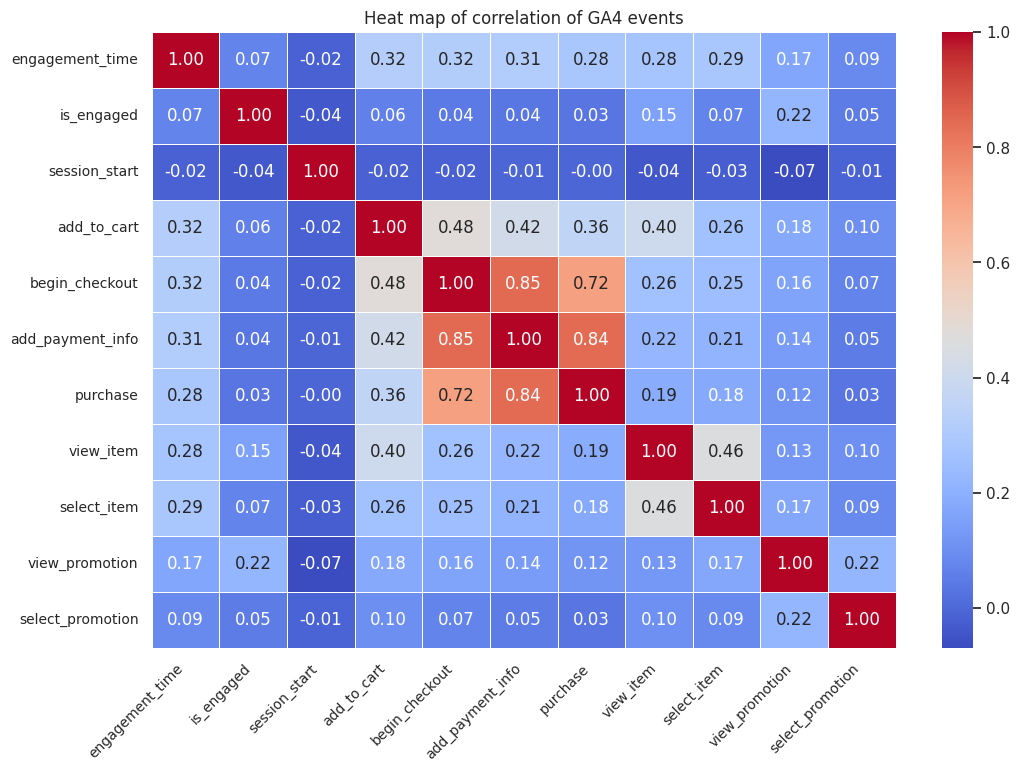

In [ ]:
numeric_df = df6.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()
# heat map
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Heat map of correlation of GA4 events')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.show()

**Conclusion:** 1. Strong positive correlations (red zones): begin_checkout ↔ add_payment_info (0.85), add_payment_info ↔ purchase (0.84), begin_checkout ↔ purchase (0.72). 2. Correlation add_to_cart ↔ begin_checkout (0.48) is significantly lower than the conversions from point 1. 3. view_promotion and select_promotion are barely correlated with purchases (~0.14 and 0.03).


###**Key Insights**
####General
Total number of sessions 116514, total number of purchase 1204, CR = 1.03%
####Traffic
Total number of countries 109.
USA leads with 52k+ sessions; African engagement is minimal.

Google organic search drives the most traffic (~37k sessions).

####Conversion Funnel

Funnel metrics sit below market benchmarks.

Add-to-cart = 3.9% (vs. 5–10% benchmark).

Major drop-off between add_to_cart → checkout.

Device type has little impact on conversion.

####Pages & Sources

Majority of pages (616/717) had zero purchases.

Page 'google.com' without page_path has 49k sessions, CR = 1.3%

Low-traffic pages often show higher CR (>5%), while high-traffic pages underperform (<3.5%).

####Promotions & Behavior

Promotions (view/select) have negligible effect on purchases(correlation 0.12/0.03 accordingly).

Weak link between engagement_time and purchase (~0.28 correlation).